In [1]:
import math
import os
import sys
sys.path.append(os.path.abspath('.')) # to run files that are away
os.environ["WANDB_SILENT"] = "true"  # Suppress WandB logs

libraries = ["torch", "numpy", "polars"]
modules   = {lib: sys.modules.get(lib) for lib in libraries}

if not modules["torch"]:
    import torch
if not modules["numpy"]:
    import numpy as np
if not modules["polars"]:
    import polars as pl

import catboost as cb
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
# from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from utils import Losses, DimensionalityEstimator


##### Import data

In [ ]:
"""Load 1 data file"""

folder       = "./ASM_data/2. marathon0"
wafer_folder = "Wafer performance"
wafer_file   = "Spatial property after step 4"
log_folder   = "Logs"
log_file     = "Step4"
extension    = ".csv"

wafer_data_file = "/".join([folder, wafer_folder, wafer_file+extension])
log_data_file   = "/".join([folder, log_folder, log_file+extension])

wafer_df        = pl.read_csv(wafer_data_file, ignore_errors=True)
print(wafer_df["#Run"].unique())

# log_df          = pl.read_csv(log_data_file, ignore_errors=True)
# parquet_subfolder= os.path.join(folder, "split_by_run")
# os.makedirs(parquet_subfolder, exist_ok=True)


shape: (20,)
Series: '#Run' [i64]
[
	1
	5
	10
	16
	49
	…
	160
	177
	181
	186
	192
]


In [221]:
"""Load WAFER data files"""

main_folder = "./ASM_data"
dict_of_wafer_files = {'file1': {'path': f"{main_folder}/2. marathon0/Wafer performance/Spatial property after step 4.csv", 'marathon': 0},
                       'file2': {'path': f"{main_folder}/3. marathon1/Wafer performance/Spatial property.csv", 'marathon': 1}}

wafer_master_df = pl.concat([
    pl.read_csv(e['path'], ignore_errors=True)
      .with_columns([
          pl.lit(e['marathon']).alias("marathon"),
          (pl.lit(e['marathon']).cast(pl.Utf8) + "_" + pl.col("#Run").cast(pl.Utf8)).alias("marathon_run")])
    for e in dict_of_wafer_files.values()], how="diagonal")

cols = wafer_master_df.columns
for c in ["marathon", "marathon_run"]:
    cols.remove(c)
insert_idx = cols.index("#Run") + 1
cols[insert_idx:insert_idx] = ["marathon", "marathon_run"]

master2_df = wafer_master_df.select(cols)

print(f"filtered df shape: {master2_df.shape}")
wafer_df = master2_df.clone()

# Save to parquet
should_we_save = False
if should_we_save:
    saving_location = f"{main_folder}/master_wafer_file.parquet"
    wafer_df.write_parquet(saving_location)
    print(f"\nConsolidated data saved to: {saving_location}")


filtered df shape: (18748, 7)


In [ ]:
# Split wafer_df by wafer, then reshape each wafer df to produce y_df

def reshape_wafer_df_to_y_and_radius(wafer_df):
    pivot_df = wafer_df.pivot(
        values="Radius (mm)",
        index=["marathon_run", "RC"],
        columns="Site #",
        aggregate_function="mean")
    pivot_df = pivot_df.rename({str(c): f"site_{c}" for c in pivot_df.columns if isinstance(c, int) or c.isdigit()})

    # Then aggregate over RC to get one row per marathon_run
    final_wafer_df = (pivot_df.group_by("marathon_run").agg(pl.all().mean()))
    final_wafer_df = final_wafer_df.sort("marathon_run")

    y_df = wafer_df.pivot(
        values="Spatial property (nm)",
        index="marathon_run",
        columns="Site #",
        aggregate_function="mean")
    y_df = y_df.sort("marathon_run")

    radius_df = wafer_df.select(["marathon_run", "Radius (mm)"])
    return y_df, radius_df

wafer_df_dict = {i: df.with_columns(pl.lit(i).alias("wafer"))
                 for i, (_, df) in enumerate(wafer_df.partition_by("RC", as_dict=True).items())}
y_df_dict       = {}
radius_df_dict  = {}
radius_wide_dict= {}

for i, df in wafer_df_dict.items():
    y_df_dict[i], radius_df_dict[i] = reshape_wafer_df_to_y_and_radius(df)

for i, df in radius_df_dict.items():
    radius_df = (df
                 .sort("marathon_run")
                 .with_columns(pl.arange(0, pl.count()).over("marathon_run").alias("radius_idx")))
    radius_wide = radius_df.pivot(
        values="Radius (mm)",
        index="marathon_run",
        columns="radius_idx",
        aggregate_function="first").sort("marathon_run")
    radius_wide_dict[i] = radius_wide


In [ ]:
# [to remove] reshaping WAFER df to (X + y)

print(wafer_df.shape)
print(wafer_df["marathon_run"].unique())

pivot_df = wafer_df.pivot(
    values="Radius (mm)",
    index=["marathon_run", "RC"],
    columns="Site #",
    aggregate_function="mean")
pivot_df = pivot_df.rename({str(c): f"site_{c}" for c in pivot_df.columns if isinstance(c, int) or c.isdigit()})

# Then aggregate over RC to get one row per marathon_run
final_wafer_df = (pivot_df.group_by("marathon_run").agg(pl.all().mean()))
final_wafer_df = final_wafer_df.sort("marathon_run")

y_df = wafer_df.pivot(
    values="Spatial property (nm)",
    index="marathon_run",
    columns="Site #",
    aggregate_function="mean")
y_df = y_df.sort("marathon_run")


(18748, 7)
shape: (43,)
Series: 'marathon_run' [str]
[
	"0_186"
	"1_156"
	"1_145"
	"1_37"
	"1_78"
	…
	"1_6"
	"0_64"
	"0_10"
	"0_1"
	"1_90"
]


(43, 110)

In [93]:
"""Load LOG data files"""

main_folder = "./ASM_data"
dict_of_log_files = {'file1': {'path': f"{main_folder}/2. marathon0/logs/Step1.csv", 'step': 1, 'marathon': 0},
                     'file2': {'path': f"{main_folder}/2. marathon0/logs/Step2.csv", 'step': 2, 'marathon': 0},
                     'file3': {'path': f"{main_folder}/2. marathon0/logs/Step3.csv", 'step': 3, 'marathon': 0},
                     'file4': {'path': f"{main_folder}/2. marathon0/logs/Step4.csv", 'step': 4, 'marathon': 0},
                     'file5': {'path': f"{main_folder}/3. marathon1/logs/Step1.csv", 'step': 1, 'marathon': 1},
                     'file6': {'path': f"{main_folder}/3. marathon1/logs/Step2.csv", 'step': 2, 'marathon': 1},
                     'file7': {'path': f"{main_folder}/3. marathon1/logs/Step3.csv", 'step': 3, 'marathon': 1},
                     'file8': {'path': f"{main_folder}/3. marathon1/logs/Step4.csv", 'step': 4, 'marathon': 1},}
step_col_name = "step_id"
df_list       = []
COMMON_ID_COLS= ['Process Time', '#Run']
COMMON_ID_COLS_MOD = [c for c in COMMON_ID_COLS if c != "#Run"] + ["marathon_run"]

for entry in dict_of_log_files.values():
    file_path = entry['path']
    step_id   = entry['step']
    marathon  = entry['marathon']
    print(f"Processing {file_path} for step {step_id} and marathon {marathon}...")

    df = pl.read_csv(file_path, ignore_errors=True)
    df = df.rename({c: c.strip().title() for c in df.columns}) #ignore capitalizations

    # Add marathon and step_id columns first
    df = df.with_columns([
        pl.lit(marathon).alias("marathon"),
        pl.lit(step_id).alias(step_col_name)])

    # Then create marathon_run column by concatenation
    df = df.with_columns([
        (pl.col("marathon").cast(pl.Utf8) + "_" + pl.col("#Run").cast(pl.Utf8)).alias("marathon_run")])

    # Rearrange columns, insert step_id and marathon_run after #Run
    cols = df.columns
    insert_idx = cols.index("#Run") + 1
    cols.remove(step_col_name)
    cols.remove("marathon_run")
    cols.insert(insert_idx, step_col_name)
    cols.insert(insert_idx + 1, "marathon_run")
    df = df.select(cols)

    # Cast numeric columns
    df = df.with_columns([
        pl.col(col).cast(pl.Float64)
        for col in df.columns
        if df[col].dtype in [pl.Int64, pl.Float32, pl.Int32]])

    # Drop single-valued columns except COMMON_ID_COLS_MOD + step_col_name
    single_val_cols = [
        col for col in df.columns
        if col not in COMMON_ID_COLS_MOD + [step_col_name]
        and df[col].n_unique() == 1]
    df = df.drop(single_val_cols)

    rename_mapping = {
        col: f"{col}_step{step_id}"
        for col in df.columns
        if col not in COMMON_ID_COLS_MOD + [step_col_name]}
    df = df.rename(rename_mapping)
    df_list.append(df)

master_df = pl.concat(df_list, how="diagonal")

# Fill nulls with 0 in numeric cols except COMMON_ID_COLS_MOD
for col in master_df.columns:
    if master_df[col].dtype.is_numeric() and col not in COMMON_ID_COLS_MOD:
        master_df = master_df.with_columns(pl.col(col).fill_null(0))

# Reorder columns: COMMON_ID_COLS_MOD + step_col_name + rest
desired_order = COMMON_ID_COLS_MOD + [step_col_name] + [
    col for col in master_df.columns if col not in COMMON_ID_COLS_MOD + [step_col_name]]
missing = [col for col in desired_order if col not in master_df.columns]
if missing:
    print("Missing columns before select:", missing)
master_df = master_df.select(desired_order)

# Remove constant-valued numeric columns (including all-0)
constant_cols = []
for col in master_df.columns:
    if master_df[col].dtype.is_numeric() and master_df.select(pl.col(col).n_unique()).item() == 1:
        constant_cols.append(col)
filtered_df = master_df.drop(constant_cols)
filtered_df = filtered_df.sort("marathon_run")

print(f"Filtered Master df shape: {filtered_df.shape}")
log_df = filtered_df.clone()

# Save to parquet
should_we_save = False
if should_we_save:
    saving_location = f"{main_folder}/master_log_file.parquet"
    filtered_df.write_parquet(saving_location)
    print(f"\nConsolidated data saved to: {saving_location}")


Processing ./ASM_data/2. marathon0/logs/Step1.csv for step 1 and marathon 0...
Processing ./ASM_data/2. marathon0/logs/Step2.csv for step 2 and marathon 0...
Processing ./ASM_data/2. marathon0/logs/Step3.csv for step 3 and marathon 0...
Processing ./ASM_data/2. marathon0/logs/Step4.csv for step 4 and marathon 0...
Processing ./ASM_data/3. marathon1/logs/Step1.csv for step 1 and marathon 1...
Processing ./ASM_data/3. marathon1/logs/Step2.csv for step 2 and marathon 1...
Processing ./ASM_data/3. marathon1/logs/Step3.csv for step 3 and marathon 1...
Processing ./ASM_data/3. marathon1/logs/Step4.csv for step 4 and marathon 1...

Filtered Master df shape: (4911263, 607)


In [183]:
# Split log_df into 4, 1 for each wafer

log_df2 = log_df.clone()
log_df2 = log_df2.rename({c: c.strip().lower() for c in log_df2.columns}) # normalize col names

wafer_log_df_dict = {}
common_cols       = [c for c in log_df2.columns if not c.startswith("rc")]

for i in range(0, 4):
    wafer_cols    = [c for c in log_df2.columns if c.startswith(f"rc{i+1}")]
    cols_to_keep  = common_cols + wafer_cols
    df_with_wafer = log_df2.select(cols_to_keep).with_columns(pl.lit(i+1).alias("wafer"))

    # reorder to put 'wafer' after 'step_id'
    cols = df_with_wafer.columns
    if "step_id" in cols:
        cols.remove("wafer")
        insert_idx = cols.index("step_id") + 1
        cols = cols[:insert_idx] + ["wafer"] + cols[insert_idx:]
        df_with_wafer = df_with_wafer.select(cols)
    wafer_log_df_dict[i] = df_with_wafer


In [184]:
df = wafer_log_df_dict[1]

zero_cols  = [c for c in df.columns if (df[c] == 0).all()]
nan_cols   = [c for c in df.columns if df[c].null_count() == df.height]
const_cols = [c for c in df.columns if df[c].n_unique() == 1]
print("Zero columns:", len(zero_cols))
print("NaN columns:", len(nan_cols))
print("Constant columns:", len(const_cols))

print((wafer_log_df_dict[0]).shape)
print((wafer_log_df_dict[1]).shape)
print((wafer_log_df_dict[2]).shape)
print((wafer_log_df_dict[3]).shape)


Zero columns: 0
NaN columns: 0
Constant columns: 1
(4911263, 474)
(4911263, 473)
(4911263, 472)
(4911263, 473)


In [ ]:
# reshape LOG_df to X

def summarize_log_df(log_df, col_to_group_by):
    "for each RUN"
    stat_map = {"mean": lambda col: pl.col(col).mean(),
                "std": lambda col: pl.col(col).std(),
                "min": lambda col: pl.col(col).min(),
                "max": lambda col: pl.col(col).max(),
                "median": lambda col: pl.col(col).median(),
                "skew": lambda col: pl.col(col).skew(),
                "kurt": lambda col: pl.col(col).kurtosis()}

    exclude_substrings = ['process time', '#run', 'wafer', 'step_id', 'marathon_run']

    allowed_types= {pl.Float64, pl.Float32, pl.Int64, pl.Int32,
                    pl.UInt64, pl.UInt32, pl.Int16, pl.UInt16, pl.Int8, pl.UInt8}
    numeric_cols = [c for c in log_df.columns
                    if not any(sub in c.lower() for sub in exclude_substrings)
                    and log_df.schema[c] in allowed_types]
    agg_exprs = []
    for stat_name, func in stat_map.items():
        for col in numeric_cols:
            agg_exprs.append(func(col).alias(f"{col}_{stat_name}"))

    result_df       = log_df.group_by(col_to_group_by).agg(agg_exprs)
    filtered_log_df = result_df.filter(pl.col(col_to_group_by).is_in(y_df[col_to_group_by]))
    return filtered_log_df

filtered_log_df = summarize_log_df(log_df, 'marathon_run')

summary_log_df_dict = {}
for i, wafer_df in wafer_log_df_dict.items():
    summary_log_df_dict[i] = summarize_log_df(wafer_df, 'marathon_run')
    summary_log_df_dict[i] = summary_log_df_dict[i].with_columns(pl.lit(i+1).alias("wafer"))

    # join radius col from radius_df_dict[i]
    summary_log_df_dict[i] = summary_log_df_dict[i].join(radius_wide_dict[i], on="marathon_run", how="left")
    cols                   = summary_log_df_dict[i].columns
    summary_log_df_dict[i] = summary_log_df_dict[i].select(["wafer"] + [c for c in cols if c != "wafer"])


(43, 3264)
(43, 3373)
(43, 3257)
(43, 3366)
(43, 3250)
(43, 3359)
(43, 3257)
(43, 3366)


{0: shape: (43, 110)
 ┌──────────────┬─────┬─────┬─────┬───┬─────┬─────┬─────┬─────┐
 │ marathon_run ┆ 0   ┆ 1   ┆ 2   ┆ … ┆ 105 ┆ 106 ┆ 107 ┆ 108 │
 │ ---          ┆ --- ┆ --- ┆ --- ┆   ┆ --- ┆ --- ┆ --- ┆ --- │
 │ str          ┆ i64 ┆ i64 ┆ i64 ┆   ┆ i64 ┆ i64 ┆ i64 ┆ i64 │
 ╞══════════════╪═════╪═════╪═════╪═══╪═════╪═════╪═════╪═════╡
 │ 0_1          ┆ 0   ┆ 25  ┆ 25  ┆ … ┆ 148 ┆ 148 ┆ 148 ┆ 148 │
 │ 0_10         ┆ 0   ┆ 25  ┆ 25  ┆ … ┆ 148 ┆ 148 ┆ 148 ┆ 148 │
 │ 0_101        ┆ 0   ┆ 25  ┆ 25  ┆ … ┆ 148 ┆ 148 ┆ 148 ┆ 148 │
 │ 0_106        ┆ 0   ┆ 25  ┆ 25  ┆ … ┆ 148 ┆ 148 ┆ 148 ┆ 148 │
 │ 0_112        ┆ 0   ┆ 25  ┆ 25  ┆ … ┆ 148 ┆ 148 ┆ 148 ┆ 148 │
 │ …            ┆ …   ┆ …   ┆ …   ┆ … ┆ …   ┆ …   ┆ …   ┆ …   │
 │ 1_6          ┆ 0   ┆ 25  ┆ 25  ┆ … ┆ 148 ┆ 148 ┆ 148 ┆ 148 │
 │ 1_73         ┆ 0   ┆ 25  ┆ 25  ┆ … ┆ 148 ┆ 148 ┆ 148 ┆ 148 │
 │ 1_78         ┆ 0   ┆ 25  ┆ 25  ┆ … ┆ 148 ┆ 148 ┆ 148 ┆ 148 │
 │ 1_84         ┆ 0   ┆ 25  ┆ 25  ┆ … ┆ 148 ┆ 148 ┆ 148 ┆ 148 │
 │ 1_90         ┆ 0

In [ ]:
# [to remove] reshaping LOG df to X

stat_map = {
    "mean": lambda col: pl.col(col).mean(),
    "std": lambda col: pl.col(col).std(),
    "min": lambda col: pl.col(col).min(),
    "max": lambda col: pl.col(col).max(),
    "median": lambda col: pl.col(col).median(),
    "skew": lambda col: pl.col(col).skew(),
    "kurt": lambda col: pl.col(col).kurtosis()}

exclude_substrings = ['process time', '#run', 'step_id', 'marathon_run']

allowed_types = {pl.Float64, pl.Float32, pl.Int64, pl.Int32,
                 pl.UInt64, pl.UInt32, pl.Int16, pl.UInt16, pl.Int8, pl.UInt8}

numeric_cols = [c for c in log_df.columns
                if not any(sub in c.lower() for sub in exclude_substrings)
                and log_df.schema[c] in allowed_types]
agg_exprs = []
for stat_name, func in stat_map.items():
    for col in numeric_cols:
        agg_exprs.append(func(col).alias(f"{col}_{stat_name}"))

result_df = log_df.group_by("marathon_run").agg(agg_exprs)
print(result_df.shape)

filtered_log_df = result_df.filter(
    pl.col("marathon_run").is_in(y_df["marathon_run"]))
print(filtered_log_df.shape)


['Process Time', 'marathon_run', 'step_id', '#Run_step1', 'Common Signal_0_step1', 'Common Signal_1_step1', 'Common Signal_5_step1', 'Common Signal_6_step1', 'Common Signal_7_step1', 'Common Signal_34_step1', 'Common Signal_35_step1', 'Common Signal_36_step1', 'Common Signal_42_step1', 'Common Signal_49_step1', 'Common Signal_50_step1', 'Common Signal_51_step1', 'Common Signal_52_step1', 'Common Signal_53_step1', 'Common Signal_54_step1', 'Common Signal_55_step1', 'Common Signal_56_step1', 'Common Signal_58_step1', 'Common Signal_59_step1', 'Common Signal_60_step1', 'Common Signal_62_step1', 'Common Signal_63_step1', 'Common Signal_66_step1', 'Common Signal_67_step1', 'Common Signal_69_step1', 'Common Signal_70_step1', 'Common Signal_71_step1', 'Common Signal_72_step1', 'Common Signal_74_step1', 'Common Signal_75_step1', 'Common Signal_76_step1', 'Common Signal_80_step1', 'Common Signal_81_step1', 'Common Signal_82_step1', 'Common Signal_83_step1', 'Common Signal_84_step1', 'Common Sig

In [242]:
from lightgbm import LGBMRegressor, early_stopping
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

def join_logs_and_wafer_df(log_df, wafer_df):
    """to get X"""
    X_full    = log_df.join(wafer_df, on="marathon_run", how="inner", suffix="_df2")
    X_full_pd = X_full.to_pandas()
    y_full_pd = y_df.sort("marathon_run").drop("marathon_run").to_pandas()
    return X_full_pd, y_full_pd

def scale_and_split_data(X_full_pd, y_full_pd):
    y_scaler      = StandardScaler()
    y_full_scaled = y_scaler.fit_transform(y_full_pd)

    X_train, X_val, y_train, y_val = train_test_split(X_full_pd, y_full_scaled, test_size=0.2, random_state=42)

    cols_to_scale = [c for c in X_train.select_dtypes(include=np.number).columns if c != "marathon_run"]
    scaler        = StandardScaler()

    X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
    X_val[cols_to_scale]   = scaler.transform(X_val[cols_to_scale])

    X_train_final = X_train.drop(columns=["marathon_run"])
    X_val_final   = X_val.drop(columns=["marathon_run"])

    return X_train_final, y_train, X_val_final, y_val, y_scaler

def predict_multioutput_lightgbm(X_train, y_train, X_val, y_val):
    n_targets = y_train.shape[1]
    y_pred    = np.zeros(y_val.shape)
    
    for i in range(n_targets):
        model = LGBMRegressor(objective='regression',
                              verbosity=-1,
                              n_estimators=1000,
                              learning_rate=0.05,
                              num_leaves=31,
                              max_depth=-1,
                              min_data_in_leaf=20)
        model.fit(X_train, y_train[:, i],
                  eval_set=[(X_val, y_val[:, i])],
                  callbacks=[early_stopping(stopping_rounds=50, verbose=False)])
        y_pred[:, i] = model.predict(X_val)
    
    rmse = mean_squared_error(y_val, y_pred) ** 0.5
    return rmse, y_pred

def predict_multioutput_catboost(X_train, y_train, X_val, y_val):
    model = MultiOutputRegressor(cb.CatBoostRegressor(verbose=0,
                                                      iterations=100,
                                                      task_type="CPU"))
    model.fit(X_train, y_train)
    y_pred_cat = model.predict(X_val)
    rmse_cat = mean_squared_error(y_val, y_pred_cat) ** 0.5
    return rmse_cat, y_pred_cat

def predict_multioutput_xgboost(X_train, y_train, X_val, y_val):
    model = MultiOutputRegressor(xgb.XGBRegressor(objective='reg:squarederror', verbosity=0))
    model.fit(X_train, y_train)
    y_pred_xgb = model.predict(X_val)
    rmse_xgb = mean_squared_error(y_val, y_pred_xgb) ** 0.5
    return rmse_xgb, y_pred_xgb

def predict_multioutput_randomforest(X_train, y_train, X_val, y_val):
    rf_model  = MultiOutputRegressor(RandomForestRegressor(random_state=42))
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_val)
    rmse_rf   = mean_squared_error(y_val, y_pred_rf) ** 0.5
    return rmse_rf, y_pred_rf

def predict_multioutput_hgb(X_train, y_train, X_val, y_val):
    model = MultiOutputRegressor(HistGradientBoostingRegressor(max_iter=100))
    model.fit(X_train, y_train)
    y_pred_hgb = model.predict(X_val)
    rmse_hgb = mean_squared_error(y_val, y_pred_hgb) ** 0.5
    return rmse_hgb, y_pred_hgb

def predict_multioutput_elasticnet(X_train, y_train, X_val, y_val):
    imputer = SimpleImputer(strategy="mean")
    base_model = make_pipeline(imputer, ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=1000))
    model = MultiOutputRegressor(base_model)
    model.fit(X_train, y_train)
    y_pred_elas = model.predict(X_val)
    rmse_elas = mean_squared_error(y_val, y_pred_elas) ** 0.5
    return rmse_elas, y_pred_elas

# ==================
# all-in-1 df

X_full_pd, y_full_pd = join_logs_and_wafer_df(filtered_log_df, final_wafer_df)
X_train_final, y_train, X_val_final, y_val, _ = scale_and_split_data(X_full_pd, y_full_pd)

# rmse_lgb, y_pred_lgb = predict_multioutput_lightgbm(X_train_final, y_train, X_val_final, y_val)
# print(f"LGBM RMSE: {rmse_lgb}")

# rmse_cat, y_pred_cat = predict_multioutput_catboost(X_train_final, y_train, X_val_final, y_val)
# print(f"Catboose RMSE: {rmse_cat}")

# rmse_rf, y_pred_rf = predict_multioutput_randomforest(X_train_final, y_train, X_val_final, y_val)
# print(f"Random Forest RMSE: {rmse_rf}")

# rmse_xgb, y_pred_xgb = predict_multioutput_xgboost(X_train_final, y_train, X_val_final, y_val)
# print(f"XGBoost RMSE: {rmse_xgb}")

# rmse_hgb, y_pred_hgb = predict_multioutput_hgb(X_train_final, y_train, X_val_final, y_val)
# print(f"HistGB RMSE: {rmse_hgb}")

# rmse_elas, y_pred_elas = predict_multioutput_elasticnet(X_train_final, y_train, X_val_final, y_val)
# print(f"Elastic RMSE: {rmse_elas}")

# =============
# loop through 4 df. we joined X previously

rmse_lgb_total = 0
rmse_cat_total = 0
# rmse_rf_total  = 0
# rmse_xgb_total = 0
# rmse_hgb_total = 0
# rmse_elas_total= 0

count = 0
for i, X_full in summary_log_df_dict.items():
    X_full_pd = X_full.to_pandas().drop(columns=["wafer"], errors='ignore')
    y_full_pd = y_df_dict[i].sort("marathon_run").drop("marathon_run").to_pandas()
    X_train_final, y_train, X_val_final, y_val, y_scaler = scale_and_split_data(X_full_pd, y_full_pd)

    print(f"Wafer {i+1}")
    rmse_lgb, y_pred_lgb = predict_multioutput_lightgbm(X_train_final, y_train, X_val_final, y_val)
    print(f"LGBM RMSE: {rmse_lgb}")

    rmse_cat, y_pred_cat = predict_multioutput_catboost(X_train_final, y_train, X_val_final, y_val)
    print(f"Catboose RMSE: {rmse_cat}")

    # rmse_rf, y_pred_rf = predict_multioutput_randomforest(X_train_final, y_train, X_val_final, y_val)
    # print(f"Random Forest RMSE: {rmse_rf}")

    # rmse_xgb, y_pred_xgb = predict_multioutput_xgboost(X_train_final, y_train, X_val_final, y_val)
    # print(f"XGBoost RMSE: {rmse_xgb}")

    # rmse_hgb, y_pred_hgb = predict_multioutput_hgb(X_train_final, y_train, X_val_final, y_val)
    # print(f"HistGB RMSE: {rmse_hgb}")

    # rmse_elas, y_pred_elas = predict_multioutput_elasticnet(X_train_final, y_train, X_val_final, y_val)
    # print(f"Elastic RMSE: {rmse_elas}")

    rmse_lgb_total += rmse_lgb
    rmse_cat_total += rmse_cat
    # rmse_rf_total  += rmse_rf
    # rmse_xgb_total += rmse_xgb
    # rmse_hgb_total += rmse_hgb
    # rmse_elas_total+= rmse_elas
    count += 1

print(f"Average LGBM RMSE: {rmse_lgb_total / count}")
print(f"Average Catboost RMSE: {rmse_cat_total / count}")
# print(f"Average rf RMSE: {rmse_rf_total / count}")
# print(f"Average xgb RMSE: {rmse_xgb_total / count}")
# print(f"Average hgb RMSE: {rmse_hgb_total / count}")
# print(f"Average elas RMSE: {rmse_elas_total / count}")


Wafer 1
LGBM RMSE: 0.6186565226161517
Catboose RMSE: 0.31633289046694024
Wafer 2
LGBM RMSE: 0.8538866170637147
Catboose RMSE: 0.6025819425710017
Wafer 3
LGBM RMSE: 0.7290242832179458
Catboose RMSE: 0.22395472798253865
Wafer 4
LGBM RMSE: 0.8902269545311402
Catboose RMSE: 0.38110881211642467
Average LGBM RMSE: 0.7729485943572381
Average Catboost RMSE: 0.38099459328422636


In [247]:
y_pred_cat.shape
y_pred_unscaled = y_scaler.inverse_transform(y_pred_cat)

type(y_pred_cat)

numpy.ndarray

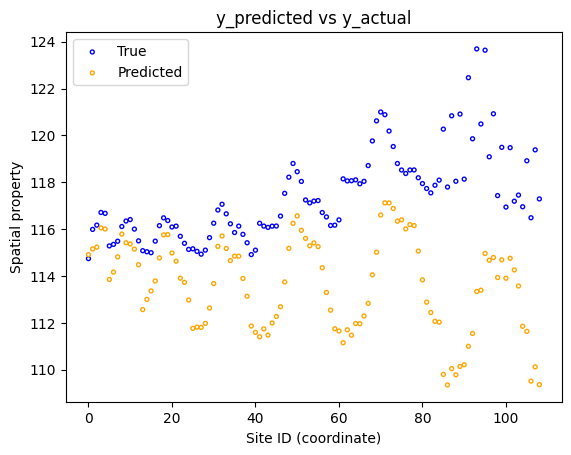

In [260]:
y_pred_unscaled = y_scaler.inverse_transform(y_pred_cat)

plt.scatter(range(len(y_full_pd.iloc[1].values)), y_full_pd.iloc[1].values,
            label="True", facecolors='none', edgecolors='blue', s=8)
plt.scatter(range(len(y_pred_unscaled[1])), y_pred_unscaled[1],
            label="Predicted", facecolors='none', edgecolors='orange', s=8)
# plt.plot(y_full_pd.iloc[1].values, label="True")
# plt.plot(y_pred_unscaled[1], label="Predicted")
plt.legend()
plt.title("y_predicted vs y_actual")
plt.xlabel("Site ID (coordinate)")
plt.ylabel("Spatial property")
plt.show()


In [ ]:
# hyperparam search

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'estimator__num_leaves': [20, 31, 40, 50],
    'estimator__max_depth': [-1, 5, 10, 20],
    'estimator__min_data_in_leaf': [10, 20, 30],
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__n_estimators': [100, 500, 1000]}

# model = MultiOutputRegressor(xgb.XGBRegressor(objective='reg:squarederror', verbosity=0))
model = MultiOutputRegressor(LGBMRegressor(objective='regression', verbosity=-1))

search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV RMSE:", (-search.best_score_)**0.5)



##### Spatial data (M)

In [ ]:
def plot_wafer_property(df, property_col, title):
    plt.figure(figsize=(9, 5))
    for rc_value, group in df.group_by("RC"):
        x = group["#Run"].to_list()
        y = group[property_col].to_list()
        plt.scatter(x, y, label=f'RC {rc_value}', s=20)
    plt.xlabel("#Run")
    plt.ylabel(property_col)
    plt.title(title)
    plt.legend()
    plt.show()

plot_wafer_property(wafer_df, "Wafer property summary 1", "Wafer Property 1")
plot_wafer_property(wafer_df, "Wafer property summary 2", "Wafer Property 2")


ColumnNotFoundError: "Wafer property summary 1" not found

<Figure size 900x500 with 0 Axes>

##### Import timeseries data (S)

In [ ]:
"""Load data and make parquet files out of it"""

should_we_save_parquet_files = False

def _save_df_as_parquet_file(df: pl.dataframe, saving_location: str):
    df.write_parquet(saving_location)

def remove_unchanging_cols_from_df_and_save(df: pl.dataframe, col_name: str, should_we_save_parquet_files: bool) -> None:
    for run_id in df[col_name].unique().to_list():
        df_per_run    = df.filter(pl.col(col_name) == run_id)
        constant_cols = [col for col in df_per_run.columns
                     if df_per_run[col].dtype in [pl.Int64, pl.Float64] and
                        #  df_per_run.select(pl.col(col).filter(pl.col(col) != 0)).height == 0]
                         df_per_run.select(pl.col(col).n_unique()).item() == 1]
        df_per_run_filtered = df_per_run.drop(constant_cols)
        saving_location = f"{parquet_subfolder}/run_{run_id}.parquet"
        if should_we_save_parquet_files:
            _save_df_as_parquet_file(df_per_run_filtered, saving_location)

remove_unchanging_cols_from_df_and_save(log_df, "#Run", should_we_save_parquet_files)

# =============
# before making funcrtion:

# if should_we_save_parquet_files:
#     for run_id in log_df["#Run"].unique().to_list():
#         df_per_run = log_df.filter(pl.col("#Run") == run_id)
#         zero_cols  = [col for col in df_per_run.columns
#                      if df_per_run[col].dtype in [pl.Int64, pl.Float64] and
#                         #  df_per_run.select(pl.col(col).filter(pl.col(col) != 0)).height == 0]
#                          df_per_run.select(pl.col(col).n_unique()).item() == 1]
#         df_per_run_filtered = df_per_run.drop(zero_cols)
#         df_per_run_filtered.write_parquet(f"{parquet_subfolder}/run_{run_id}.parquet")


##### Timeseries data (S)

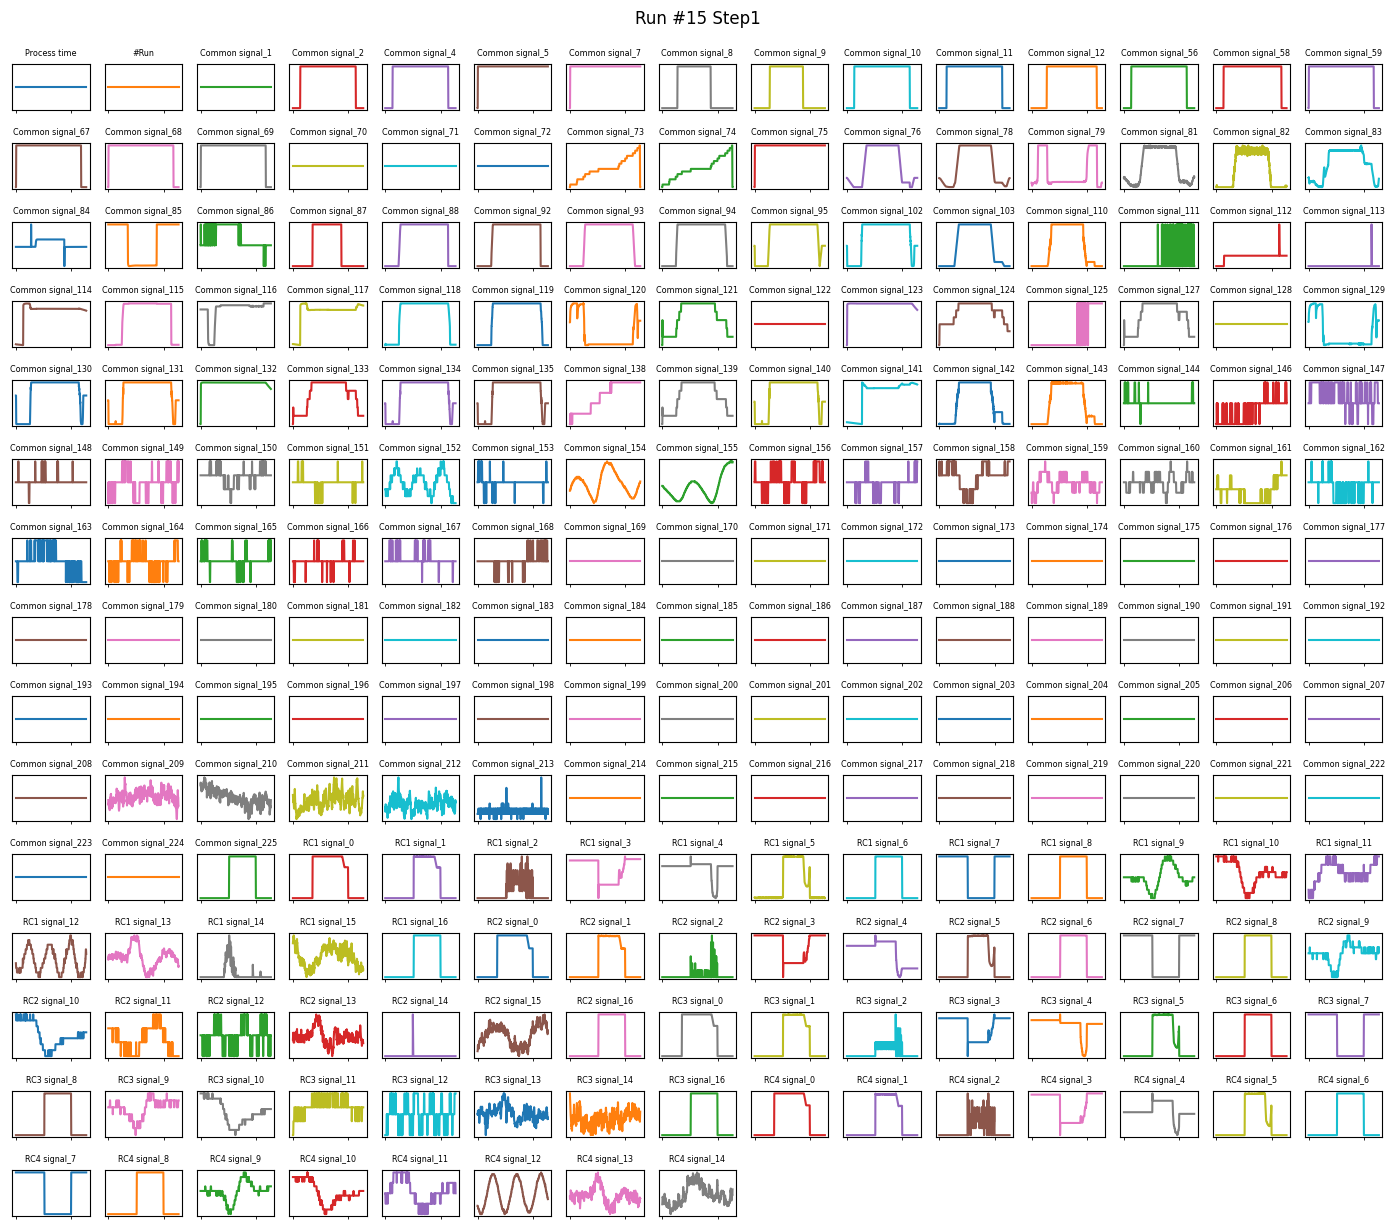

In [ ]:
run_number   = 15
parquet_file = f"./ASM_data/3. marathon1/Logs/split_by_run/run_{run_number}.parquet"
df           = pl.read_parquet(parquet_file)
df_pd        = df.to_pandas()
df_numeric   = df.select(pl.col(pl.NUMERIC_DTYPES))
X_np         = df_numeric.to_numpy()
X_scaled     = StandardScaler().fit_transform(X_np)

num_cols_to_plot = len(df_pd.columns)
num_rows         = math.ceil(math.sqrt(num_cols_to_plot))
num_cols_grid    = math.ceil(num_cols_to_plot / num_rows)

axes = df_pd.plot(subplots=True, figsize=(14, 12), layout=(num_rows, num_cols_grid), sharex=True, legend=False)

if isinstance(axes, np.ndarray):
    axes_flat = axes.flatten()
else:
    axes_flat = [axes]

column_names = df_pd.columns.tolist()

for i, ax in enumerate(axes_flat):
    if i < num_cols_to_plot: # Only set title for actual plots
        ax.set_title(column_names[i], fontsize='xx-small')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

for i in range(num_cols_to_plot, len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout()
plt.suptitle(f'Run #{run_number} {log_file}', fontsize='large', y=1.02) # Adjust y to prevent overlap
plt.show()

In [ ]:
data_dimensionality = DimensionalityEstimator.estimate_dataset_dimensionality(df)
print(f"Recommended latent layer size: {data_dimensionality:.1f}")


Recommended latent layer size: 4.5


In [ ]:
from sklearn.model_selection import train_test_split

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_np, X_test_np = train_test_split(X_scaled, test_size=0.2, random_state=42)
X_train               = torch.tensor(X_train_np, dtype=torch.float32)
X_test                = torch.tensor(X_test_np, dtype=torch.float32)


ModuleNotFoundError: No module named 'training_utils'